In [79]:
import numpy as np
import scipy as sp
import qutip as qt
import pandas as pd
import cvxpy as cp

np.set_printoptions(precision=4, suppress=True ,linewidth=np.inf, floatmode='fixed')

import matplotlib.pyplot as plt


In [80]:
Ha = np.zeros((3,3))

Ha[0][2] = -1
Ha[1][1] = 1
Ha[2][0] = -1
Ha[2][2] = 1

In [81]:
a = sp.linalg.expm(-2 * Ha)
a

array([[ 2.5016,  0.0000,  1.5217],
       [ 0.0000,  0.1353,  0.0000],
       [ 1.5217, -0.0000,  0.9798]])

In [82]:
Hb = np.zeros((2,2))

Hb[1][1] = 1

In [96]:
b = sp.linalg.expm(-2 * Hb)
b

array([[1.0000, 0.0000],
       [0.0000, 0.1353]])

In [97]:
tot_part = np.kron(a,b)

In [98]:
tot_part

array([[ 2.5016,  0.0000,  0.0000,  0.0000,  1.5217,  0.0000],
       [ 0.0000,  0.3385,  0.0000,  0.0000,  0.0000,  0.2059],
       [ 0.0000,  0.0000,  0.1353,  0.0000,  0.0000,  0.0000],
       [ 0.0000,  0.0000,  0.0000,  0.0183,  0.0000,  0.0000],
       [ 1.5217,  0.0000, -0.0000, -0.0000,  0.9798,  0.0000],
       [ 0.0000,  0.2059, -0.0000, -0.0000,  0.0000,  0.1326]])

complex term

In [112]:
var = 1j * np.log(tot_part**1j, dtype=complex)
tot_part_exp = sp.linalg.expm(var)

tot_part_exp

C:\Users\128kbps\AppData\Local\Temp\ipykernel_62208\2323094643.py:1: RuntimeWarning: invalid value encountered in power
  var = 1j * np.log(tot_part**1j, dtype=complex)
C:\Users\128kbps\AppData\Local\Temp\ipykernel_62208\2323094643.py:1: RuntimeWarning: invalid value encountered in log
  var = 1j * np.log(tot_part**1j, dtype=complex)


array([[nan+nanj, nan+nanj, nan+nanj, nan+nanj, nan+nanj, nan+nanj],
       [nan+nanj, nan+nanj, nan+nanj, nan+nanj, nan+nanj, nan+nanj],
       [nan+nanj, nan+nanj, nan+nanj, nan+nanj, nan+nanj, nan+nanj],
       [nan+nanj, nan+nanj, nan+nanj, nan+nanj, nan+nanj, nan+nanj],
       [nan+nanj, nan+nanj, nan+nanj, nan+nanj, nan+nanj, nan+nanj],
       [nan+nanj, nan+nanj, nan+nanj, nan+nanj, nan+nanj, nan+nanj]])

In [113]:
tot = np.zeros((6,6),dtype=complex)

alp = 0.01j
alpa = (1+np.sqrt(2))*0.01j

bet = -0.02j
betb = -(1+np.sqrt(2))*0.02j

In [114]:
tot[0][2] = alp
tot[0][3] = alpa
tot[1][2] = alp
tot[1][3] = alpa
tot[1][5] = -1

tot[2][4] = bet
tot[2][5] = betb
tot[3][4] = bet
tot[3][5] =betb

tot += np.transpose(tot)

In [115]:
tot[2][1] += 1
tot[2][5] += 1
tot[3][3] = 2
tot[5][5] = 2

In [116]:
t = sp.linalg.expm(1j*tot)

In [117]:
t

array([[ 1.0003+0.0002j, -0.0014-0.0050j, -0.0100-0.0001j, -0.0109-0.0171j, -0.0003-0.0001j,  0.0010-0.0046j],
       [ 0.0001+0.0003j,  0.6775-0.2489j,  0.0033-0.0152j,  0.0103-0.0184j, -0.0001-0.0003j,  0.5939-0.3775j],
       [-0.0099-0.0001j,  0.3937+1.1003j,  0.9939+0.0145j, -0.0112+0.0005j,  0.0199+0.0001j, -0.2487+0.6528j],
       [-0.0110-0.0171j,  0.0099-0.0181j,  0.0003+0.0013j, -0.4168+0.9109j,  0.0091+0.0142j, -0.0306+0.0391j],
       [-0.0003-0.0001j,  0.0028+0.0103j,  0.0200+0.0001j,  0.0090+0.0142j,  1.0003+0.0001j, -0.0020+0.0086j],
       [-0.0002-0.0006j,  0.5795-0.3584j,  0.0156+0.0318j, -0.0303+0.0389j,  0.0003+0.0007j, -0.5195+0.5186j]])

In [118]:
t @ tot_part - tot_part @ t

array([[-0.0000+0.0000j, -0.0011-0.0058j, -0.0068-0.0000j,  0.0134+0.0209j,  0.0003+0.0003j,  0.0004-0.0032j],
       [ 0.0001+0.0003j,  0.0030-0.0039j, -0.0039-0.0035j,  0.0030-0.0021j, -0.0000+0.0001j,  0.1242-0.0803j],
       [ 0.0068-0.0000j,  0.0288+0.3580j,  0.0000+0.0000j,  0.0013-0.0001j,  0.0017-0.0000j,  0.0818+0.2248j],
       [-0.0134-0.0209j, -0.0031+0.0023j,  0.0000+0.0002j,  0.0000+0.0000j, -0.0080-0.0124j, -0.0015+0.0007j],
       [-0.0003-0.0003j, -0.0001+0.0028j, -0.0017-0.0000j,  0.0080+0.0124j,  0.0000-0.0000j,  0.0008+0.0018j],
       [ 0.0001-0.0005j, -0.1272+0.0843j, -0.0006+0.0032j,  0.0013-0.0007j,  0.0000-0.0003j, -0.0030+0.0039j]])

Commutation check

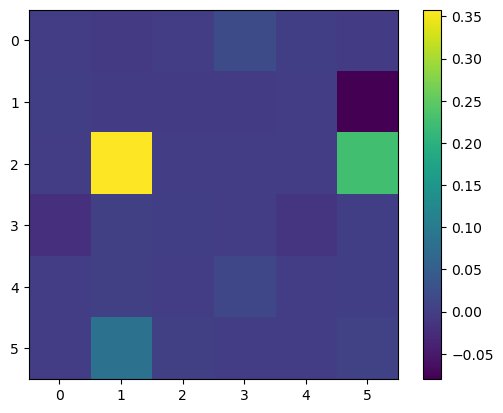

In [121]:
plt.imshow((t @ tot_part - tot_part @ t).imag)
plt.colorbar()

In [120]:
chec = t @ tot_part @ t.conj().T
chec.real

array([[ 2.5021,  0.0011,  0.0001, -0.0138,  1.5216,  0.0000],
       [ 0.0011,  0.4465, -0.1599, -0.0046, -0.0020,  0.0959],
       [ 0.0001, -0.1599,  0.9163,  0.0025,  0.0152,  0.0055],
       [-0.0138, -0.0046,  0.0025,  0.0187, -0.0076,  0.0003],
       [ 1.5216, -0.0020,  0.0152, -0.0076,  0.9798,  0.0000],
       [ 0.0000,  0.0959,  0.0055,  0.0003,  0.0000,  0.0283]])

Before evolution

<function matplotlib.pyplot.colorbar(mappable: 'ScalarMappable | ColorizingArtist | None' = None, cax: 'matplotlib.axes.Axes | None' = None, ax: 'matplotlib.axes.Axes | Iterable[matplotlib.axes.Axes] | None' = None, **kwargs) -> 'Colorbar'>

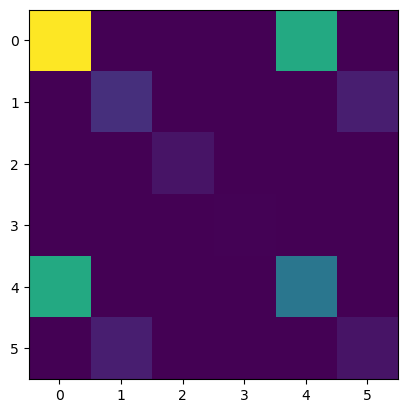

In [122]:
plt.imshow(tot_part)
plt.colorbar

After evolution

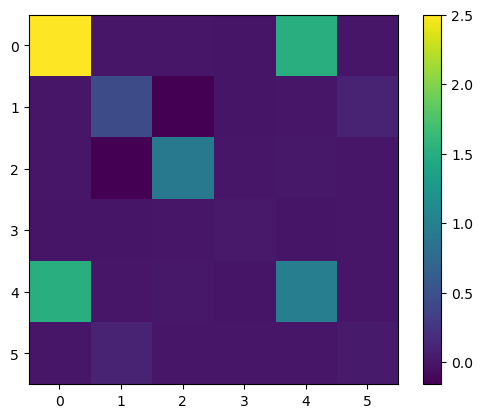

In [123]:
plt.imshow(chec.real)
plt.colorbar()

In [129]:
tens = chec.reshape(3,2,3,2)
trac = np.einsum('ibjb->ij',tens)

In [130]:
trac

array([[ 2.9486+0.0000j, -0.0045-0.0009j,  1.6175-0.0282j],
       [-0.0045+0.0009j,  0.9350-0.0000j,  0.0155-0.0003j],
       [ 1.6175+0.0282j,  0.0155+0.0003j,  1.0081-0.0000j]])

In [125]:
tens = chec.reshape(3,2,3,2)
trac = np.einsum('aiaj->ij',tens)

In [126]:
trac

array([[4.3982-0.0000j, 0.0037-0.0065j],
       [0.0037+0.0065j, 0.4935-0.0000j]])

Before evolution

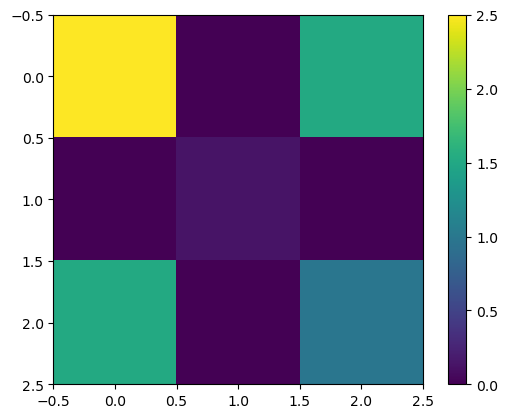

In [134]:
plt.imshow(a)
plt.colorbar()

After evolution(Trace)

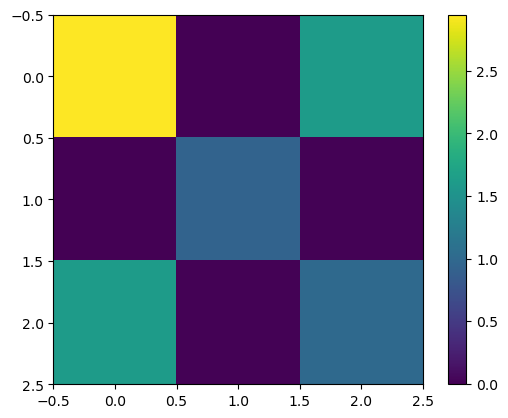

In [133]:
plt.imshow(trac.real)
plt.colorbar()